BVP FILTERING- Remove noise and unnecessary changes
1. RAW VS FILTERED BVP PLOT
2. QUALITY METRICS- MEAN, STANDARD DEVIATION, SPIKE COUNT, NOISE ESTIMATE AND PEAK COUNT. Minimum and Maximum BVP values are also plotetd.

raw data taken from empatica device

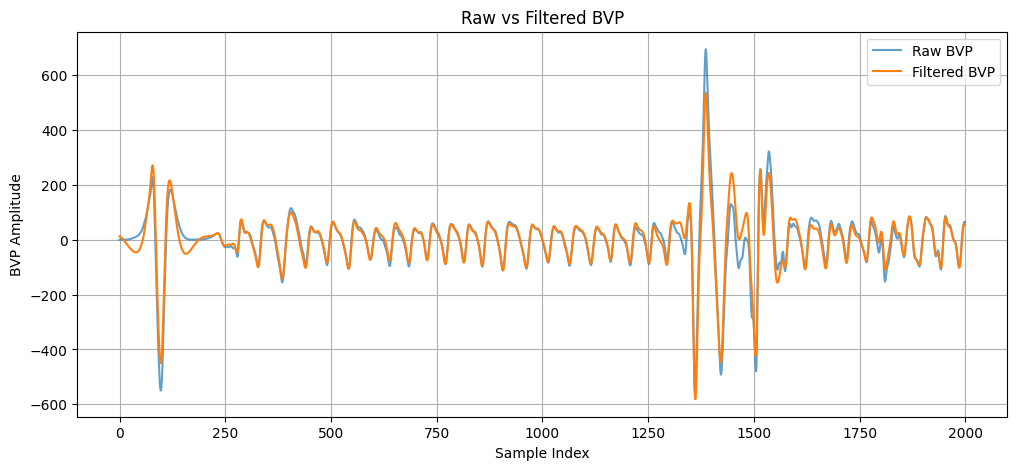

In [19]:
# load data
import pandas as pd

data = pd.read_csv("../../data/raw/WESAD/S2/S2_E4_Data/BVP.csv", header=None, names=["BVP"])
 
bvp = data['BVP'].iloc[2:].astype(float).values      #iloc= necessary, it starts from index 2

from scipy.signal import butter, filtfilt
import numpy as np

 

# Sampling frequency
fs = 64

# Bandpass range
lowcut = 0.7
highcut = 5

nyquist = fs / 2

b, a = butter(
    4,
    [lowcut/nyquist, highcut/nyquist],
    btype='band'
)

bvp_filtered = filtfilt(b, a, bvp)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

samples = 2000

plt.plot(bvp[:samples], label='Raw BVP', alpha=0.7)
plt.plot(bvp_filtered[:samples], label='Filtered BVP')

plt.title('Raw vs Filtered BVP')
plt.xlabel('Sample Index')
plt.ylabel('BVP Amplitude')
plt.legend()
plt.grid(True)

plt.show()
 

<Figure size 1500x400 with 0 Axes>

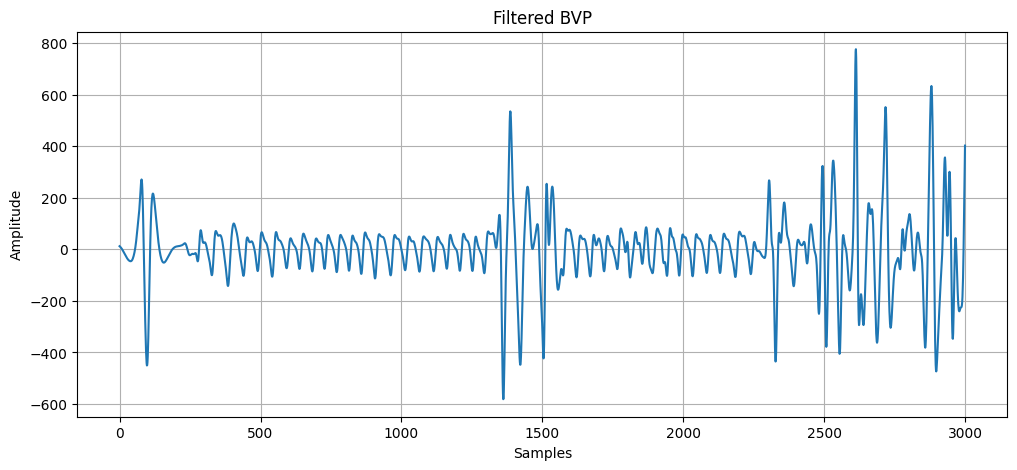

In [20]:
plt.figure(figsize=(15,4))
plt.figure(figsize=(12,5))

start = 0
end = 3000

 
plt.plot(bvp_filtered[start:end], label='Filtered BVP')


plt.title("Filtered BVP")
plt.xlabel("Samples")
plt.ylabel("Amplitude")

plt.grid(True)
plt.show()

In [21]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
raw_z = np.abs((bvp - np.mean(bvp))/np.std(bvp))
filtered_z = np.abs((bvp_filtered - np.mean(bvp_filtered))/np.std(bvp_filtered))

raw_spikes = np.sum(raw_z > 3)
filtered_spikes = np.sum(filtered_z > 3)

noise_raw = np.std(np.diff(bvp))
noise_filtered = np.std(np.diff(bvp_filtered))


# Raw BVP peaks
raw_peaks, _ = find_peaks(
    bvp,  
    prominence=0.1,      # may need tuning
    distance=32          # ~0.5 sec at 64 Hz
)

# Filtered BVP peaks
filtered_peaks, _ = find_peaks(
    bvp_filtered,
    prominence=0.1,
    distance=32
)

 
results = pd.DataFrame({
    "Metric":["Mean","Std","Spikes (>3σ)","Noise Estimate", "Peak Count"],
    "Raw":[
        np.mean(bvp),
        np.std(bvp),
        raw_spikes,
        noise_raw,
        len(raw_peaks)
    ],
    "Filtered":[
        np.mean(bvp_filtered),
        np.std(bvp_filtered),
        filtered_spikes,
        noise_filtered,
        len(filtered_peaks)
    ]
})

print(results)
print("Min (Raw):", np.min(bvp))
print("Max (Raw):", np.max(bvp))

print("Min (Filtered):", np.min(bvp_filtered))
print("Max (Filtered):", np.max(bvp_filtered))

           Metric           Raw      Filtered
0            Mean      0.003597      0.000225
1             Std     82.681627     70.299440
2    Spikes (>3σ)  13689.000000  13742.000000
3  Noise Estimate     12.788661     11.561297
4      Peak Count   9719.000000   9548.000000
Min (Raw): -893.83
Max (Raw): 1254.48
Min (Filtered): -927.0705154988166
Max (Filtered): 1060.6708340150817


| **Metric**         | **Raw** | **Filtered** |                **% Change** | **Conclusion**                                                                                               |
| ------------------ | ------: | -----------: | --------------------------: | ------------------------------------------------------------------------------------------------------------ |
| Mean               |  0.0036 |       0.0002 |                **↓ 93.74%** | Mean is brought close to zero, indicating successful removal of baseline offset.                             |
| Standard Deviation |   82.68 |        70.30 |                **↓ 14.98%** | Signal variability is reduced, indicating effective noise suppression while preserving pulse information.    |
| Spikes (>3σ)       |  13,689 |       13,742 |                 **↑ 0.39%** | Spike count remains almost unchanged, suggesting the filter preserves the main pulse features.               |
| Noise Estimate     |   12.79 |        11.56 |                 **↓ 9.60%** | High-frequency noise is reduced, resulting in a cleaner BVP signal.                                          |
| Peak Count         |   9,719 |        9,548 |                 **↓ 1.76%** | Most pulse peaks are retained, with only a small reduction due to noise removal.                             |
| Minimum Value      | -893.83 |      -927.07 | **↑ 3.72% (more negative)** | The minimum amplitude becomes slightly more negative after filtering, reflecting minor waveform adjustments. |
| Maximum Value      | 1254.48 |      1060.67 |                **↓ 15.45%** | Large amplitude fluctuations are reduced, indicating attenuation of noise and outlier peaks.                 |


data taken from pickle file

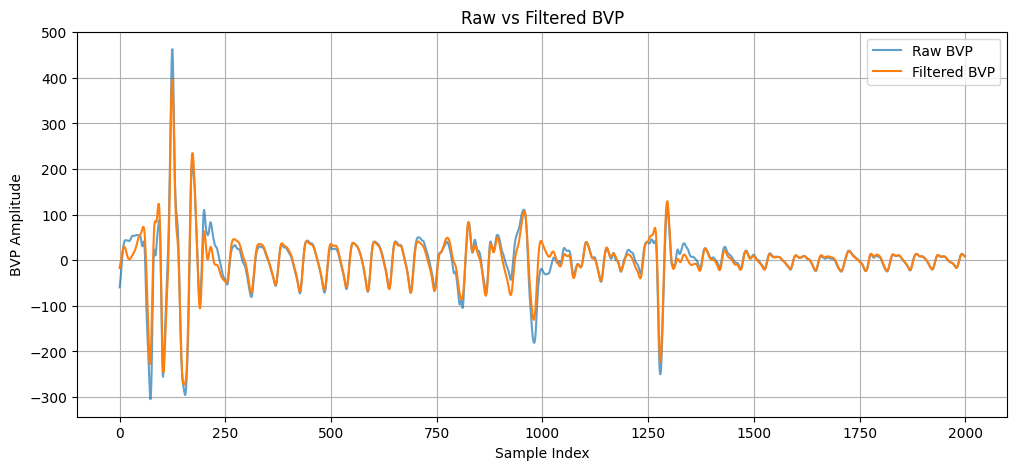

In [22]:
import pickle

file_path = "../../data/raw/WESAD/S2/S2.pkl"   # change to your file location

with open(file_path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

from scipy.signal import butter, filtfilt
import numpy as np

# Load BVP
bvp = data['signal']['wrist']['BVP'].flatten()

# Sampling frequency
fs = 64

# Bandpass range
lowcut = 0.7
highcut = 5

nyquist = fs / 2

b, a = butter(
    4,
    [lowcut/nyquist, highcut/nyquist],
    btype='band'
)

bvp_filtered = filtfilt(b, a, bvp)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

samples = 2000

plt.plot(bvp[:samples], label='Raw BVP', alpha=0.7)
plt.plot(bvp_filtered[:samples], label='Filtered BVP')

plt.title('Raw vs Filtered BVP')
plt.xlabel('Sample Index')
plt.ylabel('BVP Amplitude')
plt.legend()
plt.grid(True)

plt.show()
 

QUALITY METRICS- MEAN, STD, SPIKES, NOISE ESTIMATE, PEAK COUNT, MIN, MAX BVP VALUES

In [23]:
import numpy as np
import pandas as pd
from scipy.signal import find_peaks
raw_z = np.abs((bvp - np.mean(bvp))/np.std(bvp))
filtered_z = np.abs((bvp_filtered - np.mean(bvp_filtered))/np.std(bvp_filtered))

raw_spikes = np.sum(raw_z > 3)
filtered_spikes = np.sum(filtered_z > 3)

noise_raw = np.std(np.diff(bvp))
noise_filtered = np.std(np.diff(bvp_filtered))


# Raw BVP peaks
raw_peaks, _ = find_peaks(
    bvp,  
    prominence=0.1,      # may need tuning
    distance=32          # ~0.5 sec at 64 Hz
)

# Filtered BVP peaks
filtered_peaks, _ = find_peaks(
    bvp_filtered,
    prominence=0.1,
    distance=32
)

 
results = pd.DataFrame({
    "Metric":["Mean","Std","Spikes (>3σ)","Noise Estimate", "Peak Count"],
    "Raw":[
        np.mean(bvp),
        np.std(bvp),
        raw_spikes,
        noise_raw,
        len(raw_peaks)
    ],
    "Filtered":[
        np.mean(bvp_filtered),
        np.std(bvp_filtered),
        filtered_spikes,
        noise_filtered,
        len(filtered_peaks)
    ]
})

print(results)
print("Min (Raw):", np.min(bvp))
print("Max (Raw):", np.max(bvp))

print("Min (Filtered):", np.min(bvp_filtered))
print("Max (Filtered):", np.max(bvp_filtered))

           Metric           Raw      Filtered
0            Mean     -0.000427      0.001310
1             Std     75.871236     65.540683
2    Spikes (>3σ)  10644.000000  10529.000000
3  Noise Estimate     11.943682     10.824151
4      Peak Count   7430.000000   7291.000000
Min (Raw): -873.67
Max (Raw): 988.08
Min (Filtered): -668.0084843273672
Max (Filtered): 818.2277241362794


| Metric         |     Raw | Filtered | Interpretation                  |
| -------------- | ------: | -------: | ------------------------------- |
| Mean           | -0.0004 |   0.0013 | Essentially unchanged           |
| Std            |   75.87 |    65.54 | Reduced variability/noise       |
| Spikes (>3σ)   |   10644 |    10529 | Small reduction in outliers     |
| Noise Estimate |   11.94 |    10.82 | Noise reduced                   |
| Peak Count     |    7430 |     7291 | Heartbeat peaks preserved       |
| Min            | -873.67 |  -668.01 | Extreme negative values reduced |
| Max            |  988.08 |   818.23 | Extreme positive values reduced |
Key Observations

✅ Standard deviation decreased

75.87 → 65.54
Indicates smoothing and noise reduction.

✅ Noise estimate decreased

11.94 → 10.82
Confirms filtering removed high-frequency fluctuations.

✅ Peak count remained similar

7430 → 7291
Only ~1.9% reduction.
Suggests genuine pulse peaks were preserved.

✅ Extreme amplitudes reduced

Min and Max values moved closer to the center.
Indicates removal of artifacts and abrupt fluctuations.

Filtering improved BVP signal quality by reducing noise and amplitude extremes while preserving the physiological pulse waveform. The standard deviation decreased from 75.87 to 65.54 and the noise estimate decreased from 11.94 to 10.82. The peak count showed only a minor reduction (7430 to 7291 peaks), indicating that the filtering process successfully retained heartbeat-related information while suppressing artifacts.

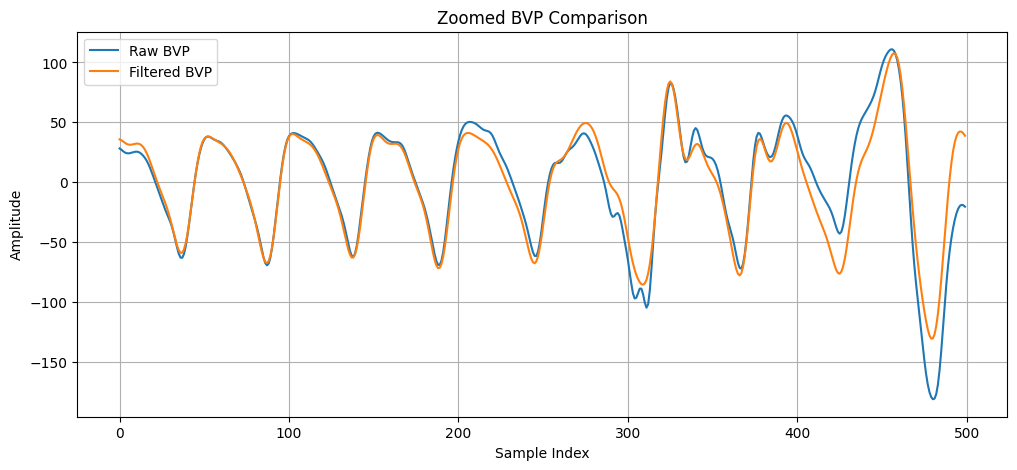

In [24]:
plt.figure(figsize=(12,5))

start = 500
end = 1000

plt.plot(bvp[start:end], label='Raw BVP')
plt.plot(bvp_filtered[start:end], label='Filtered BVP')

plt.title('Zoomed BVP Comparison')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

plt.show()